
### **Assignment** **1**
##### Name :Priya Rajkumnar Jadhav
##### Class :TY-B
##### Batch :B
##### Roll No: 23107098

Title :Identify a real-world problem in a specific industry (e.g., Agriculture, Healthcare, Finance,
Education, or Retail) and propose an AI-driven solution. Outline the problem statement, AI
methodology, expected impact, and feasibility of implementation.

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_csv("agriculture_dataset.csv")

In [ ]:
df

,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
0,0,0,0,0,0.667324,201538,3,28.207634,8.046926,0.676945,...,1.922274,84,2,2540.784327,Wheat,1,5,41.771884,0,1
1,1,1,0,0,1.459000,215854,3,82.335147,147.512332,0.414781,...,4.851381,56,3,3227.617025,Wheat,0,1,27.564635,0,1
2,0,0,0,0,0.500442,890802,3,83.865629,30.246527,0.723610,...,5.974859,38,1,4609.938146,Maize,1,8,29.510836,0,1
3,0,0,0,0,1.865161,605584,3,20.747905,6.857820,0.405611,...,2.100598,27,2,1409.716754,Maize,0,1,34.822855,0,0
4,0,1,1,1,1.392331,871732,3,22.588815,26.168558,0.465992,...,3.025669,84,4,3905.312588,Rice,0,2,15.493255,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212014,0,0,0,0,1.613700,257270,3,99.854648,39.864640,0.460258,...,2.406950,5,2,2974.199519,Maize,0,8,45.866021,0,0
212015,0,0,0,0,2.167963,875693,3,41.523453,20.314558,0.196781,...,2.443758,38,2,3134.666651,Maize,1,5,0.642406,0,1
212016,0,0,0,0,1.553286,159572,3,40.316397,149.342415,0.455641,...,1.394352,37,3,3770.711312,Maize,0,3,23.734456,0,0
212017,0,0,0,0,1.550687,859553,3,25.684100,21.912619,0.243414,...,4.573550,2,1,3263.395842,Wheat,0,4,42.983774,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212019 entries, 0 to 212018
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   High_Resolution_RGB        212019 non-null  int64  
 1   Multispectral_Images       212019 non-null  int64  
 2   Thermal_Images             212019 non-null  int64  
 3   Temporal_Images            212019 non-null  int64  
 4   Spatial_Resolution         212019 non-null  float64
 5   GPS_Coordinates            212019 non-null  int64  
 6   Field_Boundaries           212019 non-null  int64  
 7   Elevation_Data             212019 non-null  float64
 8   Canopy_Coverage            212019 non-null  float64
 9   NDVI                       212019 non-null  float64
 10  SAVI                       212019 non-null  float64
 11  Chlorophyll_Content        212019 non-null  float64
 12  Leaf_Area_Index            212019 non-null  float64
 13  Crop_Stress_Indicator      21

In [ ]:
df.isnull().sum()


,0
High_Resolution_RGB,0
Multispectral_Images,0
Thermal_Images,0
Temporal_Images,0
Spatial_Resolution,0
GPS_Coordinates,0
Field_Boundaries,0
Elevation_Data,0
Canopy_Coverage,0
NDVI,0


In [ ]:
target = "Crop_Health_Label"

drop_cols = [
    "High_Resolution_RGB", "Multispectral_Images", "Thermal_Images",
    "Temporal_Images", "GPS_Coordinates", "Field_Boundaries",
    "Ground_Truth_Segmentation", "Bounding_Boxes",
    "Spatial_Resolution", "Expected_Yield"
]

df = df.drop(columns=drop_cols)


In [ ]:
df

,Elevation_Data,Canopy_Coverage,NDVI,SAVI,Chlorophyll_Content,Leaf_Area_Index,Crop_Stress_Indicator,Temperature,Humidity,Rainfall,...,Soil_pH,Organic_Matter,Pest_Hotspots,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Crop_Type,Water_Flow,Drainage_Features,Crop_Health_Label
0,28.207634,8.046926,0.676945,0.475536,0.829063,3.107188,79,24.627325,47.240283,7.056089,...,6.085810,2.126335,0,1.922274,84,2,Wheat,41.771884,0,1
1,82.335147,147.512332,0.414781,0.325712,0.435861,1.287952,88,27.671999,44.408156,14.005230,...,6.776880,1.751158,0,4.851381,56,3,Wheat,27.564635,0,1
2,83.865629,30.246527,0.723610,0.511144,1.001452,1.229495,59,23.515820,56.268020,46.152684,...,6.078783,0.365124,0,5.974859,38,1,Maize,29.510836,0,1
3,20.747905,6.857820,0.405611,0.162857,0.962720,0.995907,11,11.473797,38.637011,15.168736,...,6.596315,2.484465,0,2.100598,27,2,Maize,34.822855,0,0
4,22.588815,26.168558,0.465992,0.269888,2.111205,0.438672,79,22.502605,64.438963,9.492281,...,7.664008,3.520753,0,3.025669,84,4,Rice,15.493255,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212014,99.854648,39.864640,0.460258,0.499035,2.155747,0.847650,43,19.587977,73.440312,18.110752,...,5.841488,2.264188,0,2.406950,5,2,Maize,45.866021,0,0
212015,41.523453,20.314558,0.196781,0.167534,0.062372,0.914123,36,26.948455,75.627371,3.079433,...,5.987856,5.504842,0,2.443758,38,2,Maize,0.642406,0,1
212016,40.316397,149.342415,0.455641,0.507295,3.826760,0.600200,3,34.895564,33.174635,44.887436,...,6.921040,4.233045,0,1.394352,37,3,Maize,23.734456,0,0
212017,25.684100,21.912619,0.243414,0.396683,0.496456,0.375939,58,21.927317,30.550094,22.895142,...,5.766334,5.163089,0,4.573550,2,1,Wheat,42.983774,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212019 entries, 0 to 212018
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Elevation_Data         212019 non-null  float64
 1   Canopy_Coverage        212019 non-null  float64
 2   NDVI                   212019 non-null  float64
 3   SAVI                   212019 non-null  float64
 4   Chlorophyll_Content    212019 non-null  float64
 5   Leaf_Area_Index        212019 non-null  float64
 6   Crop_Stress_Indicator  212019 non-null  int64  
 7   Temperature            212019 non-null  float64
 8   Humidity               212019 non-null  float64
 9   Rainfall               212019 non-null  float64
 10  Wind_Speed             212019 non-null  float64
 11  Soil_Moisture          212019 non-null  float64
 12  Soil_pH                212019 non-null  float64
 13  Organic_Matter         212019 non-null  float64
 14  Pest_Hotspots          212019 non-nu

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["Crop_Type"] = le.fit_transform(df["Crop_Type"])


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212019 entries, 0 to 212018
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Elevation_Data         212019 non-null  float64
 1   Canopy_Coverage        212019 non-null  float64
 2   NDVI                   212019 non-null  float64
 3   SAVI                   212019 non-null  float64
 4   Chlorophyll_Content    212019 non-null  float64
 5   Leaf_Area_Index        212019 non-null  float64
 6   Crop_Stress_Indicator  212019 non-null  int64  
 7   Temperature            212019 non-null  float64
 8   Humidity               212019 non-null  float64
 9   Rainfall               212019 non-null  float64
 10  Wind_Speed             212019 non-null  float64
 11  Soil_Moisture          212019 non-null  float64
 12  Soil_pH                212019 non-null  float64
 13  Organic_Matter         212019 non-null  float64
 14  Pest_Hotspots          212019 non-nu

In [ ]:
X = df.drop(columns=["Crop_Health_Label"])
y = df["Crop_Health_Label"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Logistic Regresssion

In [ ]:
from sklearn.linear_model import LogisticRegression
le=LogisticRegression(max_iter=3000)
le.fit(X_train,y_train)

LogisticRegression(max_iter=3000)

In [ ]:
ypred=le.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test,ypred)
acc

0.7010187718139799

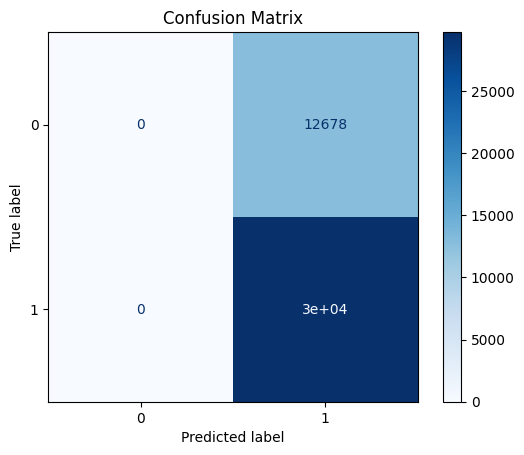

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


cm = confusion_matrix(y_test, ypred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



In [ ]:
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_classifier.predict(X_test)

In [ ]:
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy Score: {acc_nb}")

Naive Bayes Accuracy Score: 0.7010187718139799


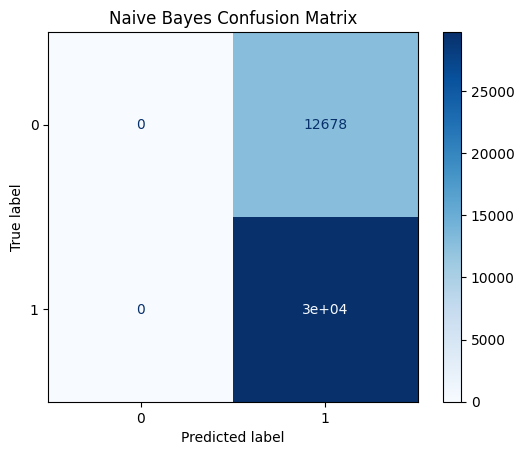

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_classifier.classes_)
disp_nb.plot(cmap=plt.cm.Blues)
plt.title('Naive Bayes Confusion Matrix')
plt.show()